## Tutorial: Measure plant and plot height with PlantCV-Geospatial

This tutorial uses PlantCV-Geospatial v1.0. Last updated July 25, 2026. You must have PlantCV and PlantCV-Geospatial installed to use this tutorial. For installation instructions, visit [this page for PlantCV](https://docs.plantcv.org/en/stable/installation/) and [this page for PlantCV Geospatial](https://docs.plantcv.org/projects/geospatial/en/latest/installation/). 

Data used in this tutorial is availalbe from the following publicly available data: 

    Wilde, S. C. & Cope, D. A. Maize G2F UAV Data, College Station, TX 2019. CyVerse Data Commons https://doi.org/10.25739/D9GT-HV94 (2020).
  


This tutorial is an example workflow for analyzing height for regions in a geojson shapefile using regional percentiles and a canopy height model. This will cover basics of:
  - Reading in images with `plantcv-geospatial` (`gcv`)
  - Using the `field_layout` class in `gcv`
  - Image classes in `gcv`
  - Using the `InteractiveShapes` class to annotate your images
  - Height measurement via a percentile method and a canopy height model.

## Step 1: Load in packages and specify parameters

First, we load `plantcv.geospatial`. Here we also load the main `plantcv.plantcv.` package so that we can set our debug parameter and for checking our `outputs` class later.

In [1]:
from plantcv import geospatial as gcv
from plantcv import plantcv as pcv
pcv.params.debug = "plot"

Those familiar with `PlantCV` may be used to interacting with `pcv.params` to control debug behavior, text thickness, and other such variables that are used in many functions.

In `gcv` we add a similar [singleton class called `field_layout`](https://docs.plantcv.org/projects/geospatial/en/latest/Field_layout/) which you can use to keep several useful metrics about your particular field data. See the linked docs for a full list of attributes and for where they are used.

![Field Layout Terminology](img/row_plot_vocab.png)

In [2]:
#Using the field layout of the data we are analyzing, we will specify the number of ranges, columns, and the spacing between them, as well as the range length and row length. 

gcv.field_layout.num_ranges = 4
gcv.field_layout.num_columns = 31
gcv.field_layout.range_spacing = 10
gcv.field_layout.range_length = 5
gcv.field_layout.row_length = 2

## Step 2: Import (aka read) in an image. 
With our parameters set we are ready to read in an image.

`gcv.read` currently supports `.geotif` and select `.netcdf` files (as more accepted standards come out of the netcdf format we may expand to include more supported types there).

`gcv.read.geotif` is used here to read in a grayscale `.tif` file. There are four arguments to `read.geotif`:
- 1: 'filename': The path to a file
- 2: 'bands': Bands to read, defaults to "R,G,B" but supports R, G, B, RE, N, NIR, and GRAY.
- 3: 'cropto': Defaults to None but can be a path to a shapefile to crop the image to.
- 4: 'cutoff': Defaults to None but can be a percentile above which to remove points in grayscale images.


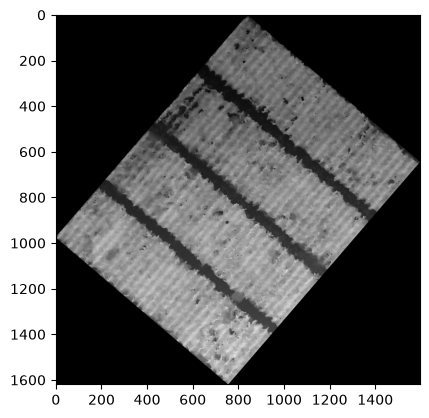

In [3]:
#Here, we will title the imported image "dsm" becasue it is a digital surface model. 

dsm = gcv.read.geotif("img/cropped.tif", bands="gray")

To keep track of important metadata when handling these images `gcv` includes two image classes, `GEO` and `DSM`.

`GEO` objects hold any multi-channel geospatial images and are a subclass of `numpy.ndarray` with special methods/attributes for a thumbnail (`thumb`), coordinate reference system (`crs`), transformations (`transfrom`), nodata values (`nodata`), wavelengths (`wavelengths`, which are numerical wavelength values found in the image metadata), and default wavelengths (`default_wavelengths`, which are a lookup table of defaults if a user inputs band names, such as NIR), and retrieving array slices from a wavelength (`get_wavelength(wavelength)`) as another `GEO` object.

`DSM` or "**D**igital **S**urface **M**odel" objects are essentially the same thing but as a grayscale image, which is a useful differentiation for the `gcv` internals.

Here we will work with a `DSM` object, and methods up to height calculation would be the same for a `GEO` object.

In [4]:
#If you want to check the type of the imported image, you can use the following command:

type(dsm)

plantcv.geospatial.images.DSM

## Step 3: Annotate field coordinates

The next feature of `gcv` that we'll look at is the `InteractiveShapes` class. This class works with a `napari` viewer to allow for annotation of important field coordinates.

This next cell opens a Napari window, where you can create layers. The call to `InteractiveShapes` will default to making a polygon layer called `field_boundary`, which is an important first step for our downstream analysis. In this particular case there is only one section of the field that we'll care about but often you will have to select your target area from a larger orthomosaic. Run the next cell, then draw the field boundary in the `field_boundary` layer in Napari.
In Napari, select `field_boundary` (it may already be selected), choose the polygon tool (the shape next to the rectangle icon), and draw the field outline by clicking vertices, then press enter. In order for the autogrid function to align properly, always start in the upper left corner of a field when drawing the boundary. 

The `InteractiveShapes` class has a `close()` method, but keep the viewer open for now to see what other functions do with it.

In [5]:
# Open the Napari viewer to interactively draw the field boundary. 

editor = gcv.create_shapes.InteractiveShapes(
    img=dsm,
    viewer_type="napari",
    field_layer="field_boundary",
    show=True
    )

The `InteractiveShapes` class has several helpful methods, the first of whcih is `to_shapes`. This lets us save a polygon/rectangle layer to a geojson file.

In [6]:
#Save the polygon/rectangle layer of the field boundary as a geojson file named "vertices". 

vertices = editor.to_shapes(dest="boundary_points.geojson", layername="field_boundary")

## Step 4: Automatically define plots in the field. 

Next, since we defined traits of our field in the `field_layout` class we can call `grid` and `plots` to automatically cut our field into plots.
If you have a less perfect rectangle then you may need to use [other methods](https://docs.plantcv.org/projects/geospatial/en/latest/shapes_grid_from_coords/) to label your plots.

In [7]:
# Open the Napari viewer to add the grid and plots to the field, which will be populated based on the parameters set at the beginning of this tutorial. 

editor.grid()
editor.plots()

Now we can save that layer as another geojson file.

In [8]:
#Save the polygon/rectangle layer of the plot boundaries as the geojson file named "vertices" that already contains the field boundaries. 

vertices = editor.to_shapes(dest="plots.geojson", layername="Plots")

## Step 5: Analyze height. 

Now we are ready to analyze height. 

We will use a method uses a percentile cutoff to represent the soil and the plants. The `analyze.height_percentile` function is a vectorized method for height estimation per region in a shapefile. It calculates the soil elevation as the lower percentile and uses the upper percentile as plot elevation. This will save the lower, upper, and difference (plant height) to your outputs.

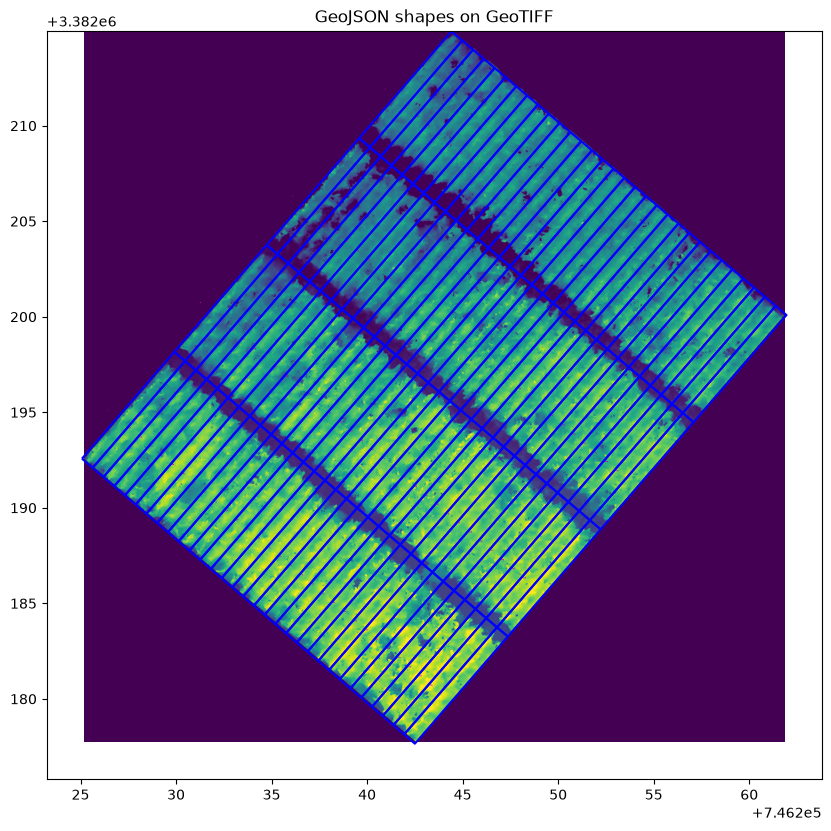

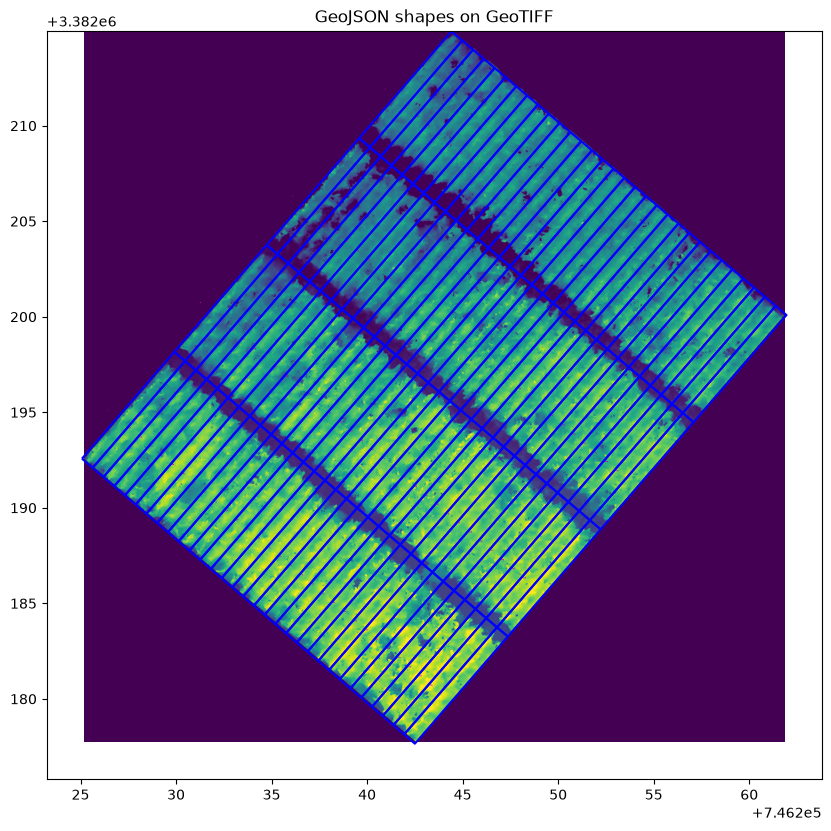

In [9]:
# Analyze height of each region in the shapefile.
# A plot will appear showing plant height and a grid of each plot boundary. 

gcv.analyze.height_percentile(dsm, geojson="plots.geojson")

In [10]:
#To see the results of the analysis, you can use the following command to view the observations in the output file.

pcv.outputs.observations["default_1"]

{'soil_elevation': {'trait': 'dsm_mean_below_percentile_25',
  'method': 'plantcv-geospatial.analyze.height',
  'scale': 'metre',
  'datatype': "<class 'float'>",
  'value': 37.50241470336914,
  'label': 'metre'},
 'plant_elevation': {'trait': 'dsm_mean_above_percentile_90',
  'method': 'plantcv-geospatial.analyze.height',
  'scale': 'metre',
  'datatype': "<class 'float'>",
  'value': 37.89509582519531,
  'label': 'metre'},
 'plant_height': {'trait': 'height',
  'method': 'plantcv-geospatial.analyze.height',
  'scale': 'metre',
  'datatype': "<class 'float'>",
  'value': 0.3926811218261719,
  'label': 'metre'}}

A second available method uses a bare ground measurement to determine plant height. The `analyze.chm` function stands for **C**anopy **H**eight **M**odel. This function is a vectorized method to subtract the bare ground DSM from a DSM with plants included. This example data does not include a bare ground height, so cannot use this function. If a bareground flight were present, the function would be used like this: 

```python
hist = gcv.analyze.chm(dsm, geojson="plots.geojson")
```

## Step 6: Save the results. 
We can save the results per standard `pcv.outputs` behavior once our analysis is complete.

In [11]:
# Save the results of the analysis to a JSON file named "res.json". 

pcv.outputs.save_results("res.json")

We hope that this is a useful getting started guide for height analysis in `PlantCV-Geospatial`.

For details about functions please see the [online documentation](https://docs.plantcv.org/projects/geospatial/en/latest/).

For questions about the docs, bug reports, feature requests, and other issues please open a [github issue](https://github.com/danforthcenter/plantcv-geospatial/issues) and our team will try to help!